In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy.integrate import solve_ivp


/home/anagha/anaconda3/lib/python3.9/site-packages/scipy/__init__.py:155: UserWarning: A NumPy version >=1.18.5 and <1.25.0 is required for this version of SciPy (detected version 1.26.3
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
def hill(X, X0, lambda_, n):
    H1 = (X ** n) / (X0 ** n + X ** n)
    H2 = (X0 ** n) / (X0 ** n + X ** n)
    return H2 + lambda_ * H1

def interactions(t, x, gamma_A, gamma_B, g_A, g_B, A0B, B0A, A0A, B0B, nAtoB, nBtoA, nAtoA, nBtoB, lambda_AtoB, lambda_BtoA, lambda_AtoA, lambda_BtoB):
    dxdt = np.zeros(2)
    dxdt[0] = g_A * hill(x[1], B0A, lambda_BtoA, nBtoA) - gamma_A * x[0]
    dxdt[1] = g_B * hill(x[0], A0B, lambda_AtoB, nAtoB) - gamma_B * x[1]
    return dxdt

In [3]:
domain = (0, 500)

gamma_A_list = np.linspace(0.1, 5, 100).tolist()
# Parameter lists with test values
number_of_values_of_para=len(gamma_A_list)
#gamma_A_list = [0.5] * number_of_values_of_para #np.arange(0.1, 2.6, 0.1).tolist()
gamma_B_list = [0.5] * number_of_values_of_para
g_A_list = [10] * number_of_values_of_para
g_B_list = [10] * number_of_values_of_para
A0B_list = [2] * number_of_values_of_para #np.linspace(1, 60, 100).tolist()
B0A_list = [2] * number_of_values_of_para
A0A_list = [80] * number_of_values_of_para
B0B_list = [80] * number_of_values_of_para
nBtoA_list = [5] * number_of_values_of_para
nAtoA_list = [4] * number_of_values_of_para
nBtoB_list = [4] * number_of_values_of_para
nAtoB_list = [4] * number_of_values_of_para #np.linspace(1, 20, 20).tolist() #
lambda_AtoB_list =  [0.1] * number_of_values_of_para #np.linspace(0.1, 0.17, 40).tolist()
lambda_BtoA_list = [0.1] * number_of_values_of_para
lambda_AtoA_list = [5] * number_of_values_of_para
lambda_BtoB_list = [5] * number_of_values_of_para
conc_a1_list = []
conc_b1_list = []
conc_a2_list = []
conc_b2_list = []
p_1_list = []
p_2_list = []

data = []
param_values = list(zip(gamma_A_list, gamma_B_list, g_A_list, g_B_list, A0B_list, B0A_list, A0A_list, B0B_list, nAtoB_list, nBtoA_list, nAtoA_list, nBtoB_list, lambda_AtoB_list, lambda_BtoA_list, lambda_AtoA_list, lambda_BtoB_list))

In [ ]:
for params in param_values:
    gamma_A, gamma_B, g_A, g_B, A0B, B0A, A0A, B0B, nAtoB, nBtoA, nAtoA, nBtoB, lambda_AtoB, lambda_BtoA, lambda_AtoA, lambda_BtoB = params

    final_A_values = []

    for _ in range(200):
        A = 10 * np.random.rand()
        B = 10 * np.random.rand()

        sol = solve_ivp(interactions, domain, [A, B], args=(
            gamma_A, gamma_B, g_A, g_B, A0B, B0A, A0A, B0B,
            nAtoB, nBtoA, nAtoA, nBtoB, lambda_AtoB, lambda_BtoA, lambda_AtoA, lambda_BtoB),
            method='RK45', t_eval=np.linspace(domain[0], domain[1], 10000)
        )

        final_A_values.append(sol.y[0][-1] / (g_A / gamma_A))

    final_A_values = np.array(final_A_values)
    final_A_values.sort()

    error_margin = 1.001e-2
    unique_A_values = []
    for value in final_A_values:
        if not any(abs(value - u) <= error_margin for u in unique_A_values):
            unique_A_values.append(value)

    unique_A_values.sort()

    if len(unique_A_values) == 1:
        if unique_A_values[0] > 0.5:
            conc_a1_list.append("NA")
            conc_a2_list.append(unique_A_values[0])
            p_1_list.append(0)
            p_2_list.append(1)
        else:
            conc_a2_list.append("NA")
            conc_a1_list.append(unique_A_values[0])
            p_2_list.append(0)
            p_1_list.append(1)           
        
    else:
        p_1 = [x for x in final_A_values if abs(x - unique_A_values[0]) <= error_margin]
        p_2 = [x for x in final_A_values if abs(x - unique_A_values[1]) <= error_margin]

        conc_a1_list.append(unique_A_values[0])
        conc_a2_list.append(unique_A_values[1])
        p_1_list.append(len(p_1) / 200)
        p_2_list.append(len(p_2) / 200)

In [79]:
df = pd.DataFrame({
    "gamma_A": gamma_A_list,
    "gamma_B": gamma_B_list,
    "g_A": g_A_list,
    "g_B": g_B_list,
    "A0B": A0B_list,
    "B0A": B0A_list,
    "A0A": A0A_list,
    "B0B": B0B_list,
    "nAtoB": nAtoB_list,
    "nBtoA": nBtoA_list,
    "nAtoA": nAtoA_list,
    "nBtoB": nBtoB_list,
    "lambda_AtoB": lambda_AtoB_list,
    "lambda_BtoA": lambda_BtoA_list,
    "lambda_AtoA": lambda_AtoA_list,
    "lambda_BtoB": lambda_BtoB_list,
    "conc_a1": conc_a1_list,
    "conc_a2": conc_a2_list,
    "p1": p_1_list,
    "p2": p_2_list
})
df = df.sort_values(by="gamma_A")



In [80]:
param_dict = {
    "gamma_A": gamma_A_list,
    "gamma_B": gamma_B_list,
    "g_A": g_A_list,
    "g_B": g_B_list,
    "A0B": A0B_list,
    "B0A": B0A_list,
    "A0A": A0A_list,
    "B0B": B0B_list,
    "nAtoB": nAtoB_list,
    "nBtoA": nBtoA_list,
    "nAtoA": nAtoA_list,
    "nBtoB": nBtoB_list,
    "lambda_AtoB": lambda_AtoB_list,
    "lambda_BtoA": lambda_BtoA_list,
    "lambda_AtoA": lambda_AtoA_list,
    "lambda_BtoB": lambda_BtoB_list,
    "conc_a1": conc_a1_list,
    "conc_a2": conc_a2_list,
    "p1": p_1_list,
    "p2": p_2_list
}

# Print lengths
for key, val in param_dict.items():
    print(f"{key}: {len(val)}")

# Optional: check if all lengths are equal
lengths = [len(v) for v in param_dict.values()]
if len(set(lengths)) == 1:
    print("same length")
else:
    print("check for length mismatch somewhere :)")

gamma_A: 100
gamma_B: 100
g_A: 100
g_B: 100
A0B: 100
B0A: 100
A0A: 100
B0B: 100
nAtoB: 100
nBtoA: 100
nAtoA: 100
nBtoB: 100
lambda_AtoB: 100
lambda_BtoA: 100
lambda_AtoA: 100
lambda_BtoB: 100
conc_a1: 100
conc_a2: 100
p1: 100
p2: 100
same length


In [81]:
df

,gamma_A,gamma_B,g_A,g_B,A0B,B0A,A0A,B0B,nAtoB,nBtoA,nAtoA,nBtoB,lambda_AtoB,lambda_BtoA,lambda_AtoA,lambda_BtoB,conc_a1,conc_a2,p1,p2
88,0.5,0.5,10,53.444444,2,2,80,80,5,5,4,4,0.1,0.02,5,5,0.019994,NA,1.00,0.00
89,0.5,0.5,10,54.040404,2,2,80,80,5,5,4,4,0.1,0.02,5,5,0.01999,NA,1.00,0.00
90,0.5,0.5,10,54.636364,2,2,80,80,5,5,4,4,0.1,0.02,5,5,0.019999,NA,1.00,0.00
91,0.5,0.5,10,55.232323,2,2,80,80,5,5,4,4,0.1,0.02,5,5,0.019997,NA,1.00,0.00
92,0.5,0.5,10,55.828283,2,2,80,80,5,5,4,4,0.1,0.02,5,5,0.019995,NA,1.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15,0.5,0.5,10,9.939394,2,2,80,80,5,5,4,4,0.1,0.02,5,5,0.019992,0.513841,0.72,0.28
97,0.5,0.5,10,58.808081,2,2,80,80,5,5,4,4,0.1,0.02,5,5,0.019994,NA,1.00,0.00
98,0.5,0.5,10,59.404040,2,2,80,80,5,5,4,4,0.1,0.02,5,5,0.019993,NA,1.00,0.00
99,0.5,0.5,10,60.000000,2,2,80,80,5,5,4,4,0.1,0.02,5,5,0.019993,NA,1.00,0.00


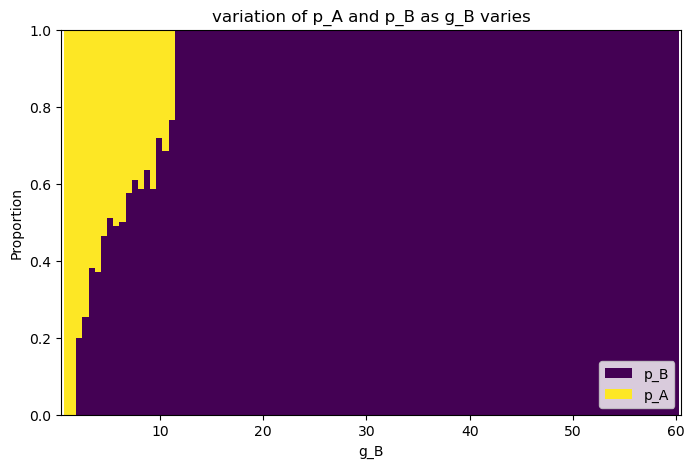

In [86]:
#df["conc_a1"] = np.round(df["conc_a1"], 4)
#df["conc_a2"] = np.round(df["conc_a2"], 4)
viridis = cm.get_cmap("viridis")

color_p2 = viridis(300)
color_p1 = viridis(0)
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(df["g_B"], df["p1"], color=color_p1, label='p_B', width=0.6)
ax.bar(df["g_B"], df["p2"], bottom=df["p1"], color=color_p2, label='p_A', width=0.6)
'''for i in range(len(df)):
    ax.text(df["g_A"].iloc[i], 0, df["conc_a1"].iloc[i], ha='center', va='bottom', rotation=90)
    
for i in range(len(df)):
    ax.text(df["g_A"].iloc[i], 0, df["conc_a2"].iloc[i], ha='center', va='top', rotation=90)
'''
ax.set_xlabel("g_B")
ax.set_ylabel("Proportion")
ax.set_title("variation of p_A and p_B as g_B varies")
ax.legend(loc='lower right')
ax.set_xlim(0.45, 60.5) 
ax.set_ylim(0, 1) 
plt.show()
